## Part 1: Lab Setup
### 1.1 Install Libraries

In [7]:
!pip install tensorflow matplotlib
!pip install numpy<2

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/opt_einsum-3.4.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.12.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.0.dev0-py3.12.egg is deprecated. pip 25.1 wil

### 1.2 Import Required Packages

In [8]:
import tensorflow as tf
import numpy as np
import os
import time
import matplotlib.pyplot as plt

## Part 2: Load and Preprocess Shakespeare Dataset

In [9]:
path_to_file = tf.keras.utils.get_file(
    "shakespeare.txt",
    "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"
)

text = open(path_to_file, "rb").read().decode(encoding="utf-8")

print(f"Length of text: {len(text)} characters")
print(text[:500])

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Length of text: 1115394 characters
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


### 2.1 Character Vocabulary

In [10]:
vocab = sorted(set(text))

char2idx = {u: i for i, u in enumerate(vocab)}
idx2char = np.array(vocab)

text_as_int = np.array([char2idx[c] for c in text])

print(f"Vocabulary size: {len(vocab)}")
print("Example characters:", vocab[:20])
print("Encoded sample:", text_as_int[:20])

Vocabulary size: 65
Example characters: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G']
Encoded sample: [18 47 56 57 58  1 15 47 58 47 64 43 52 10  0 14 43 44 53 56]


### 2.2 Create Training Sequences

In [11]:
seq_length = 100
examples_per_epoch = len(text) // (seq_length + 1)

char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

sequences = char_dataset.batch(seq_length + 1, drop_remainder=True)

def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

dataset = sequences.map(split_input_target)

for input_example, target_example in dataset.take(1):
    print("Input length:", len(input_example))
    print("Target length:", len(target_example))
    print("Input sample:")
    print("".join(idx2char[input_example.numpy()[:80]]))
    print("\nTarget sample:")
    print("".join(idx2char[target_example.numpy()[:80]]))

W0000 00:00:1786982202.605354    5768 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1786982202.609765    5768 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1786982202.806118    5768 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5092 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Input length: 100
Target length: 100
Input sample:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

Target sample:
irst Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.



## Part 3: Prepare Dataset for Training

In [12]:
BATCH_SIZE = 64
BUFFER_SIZE = 10000

data = (
    dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

for input_batch, target_batch in data.take(1):
    print("Input batch shape:", input_batch.shape)
    print("Target batch shape:", target_batch.shape)

Input batch shape: (64, 100)
Target batch shape: (64, 100)


## Part 4: Build RNN Model
### 4.1 LSTM Model Definition

In [13]:
def build_model(vocab_size, embedding_dim, rnn_units, cell_type="lstm"):
    model = tf.keras.Sequential(name=f"character_level_{cell_type}")

    model.add(tf.keras.layers.Embedding(vocab_size, embedding_dim))

    if cell_type == "lstm":
        model.add(tf.keras.layers.LSTM(rnn_units, return_sequences=True))
    elif cell_type == "gru":
        model.add(tf.keras.layers.GRU(rnn_units, return_sequences=True))
    else:
        raise ValueError("cell_type must be either 'lstm' or 'gru'.")

    model.add(tf.keras.layers.Dense(vocab_size))

    return model


vocab_size = len(vocab)
embedding_dim = 256
rnn_units = 1024

model_lstm = build_model(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    rnn_units=rnn_units,
    cell_type="lstm"
)

model_lstm.summary()

Model: "character_level_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 4.2 Compile the Model

In [14]:
def loss(labels, logits):
    return tf.keras.losses.sparse_categorical_crossentropy(
        labels,
        logits,
        from_logits=True
    )

model_lstm.compile(
    optimizer="adam",
    loss=loss
)

## Part 5: Train the LSTM Model

In [15]:
EPOCHS = 10

start_time = time.time()

history_lstm = model_lstm.fit(
    data,
    epochs=EPOCHS
)

training_time_lstm = time.time() - start_time

print(f"LSTM training time: {training_time_lstm:.2f} seconds")

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1786982230.306102    5925 cuda_dnn.cc:461] Loaded cuDNN version 92000


172/172 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - loss: 2.6771
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 1.9733
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 1.7211
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 1.5765
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 1.4853
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 1.4232
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 1.3766
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 1.3384
Epoch 9/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 1.3066
Epoch 10/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 1.2775
LSTM training time: 90.70 seconds


### Plot Training Loss

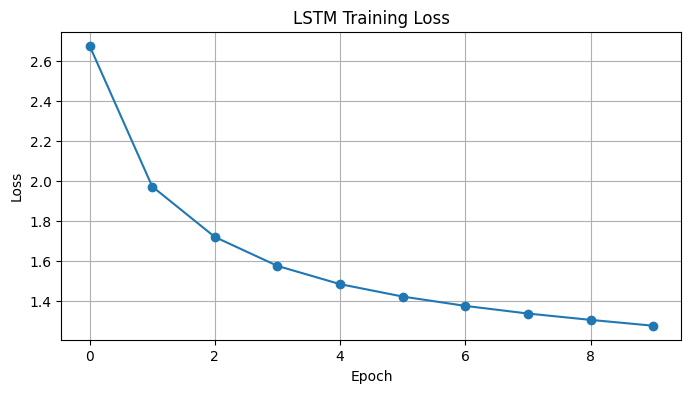

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(history_lstm.history["loss"], marker="o")
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## Part 6: Text Generation Function
### 6.1 One-Step Generation

In [17]:
def generate_text(model, start_string, temperature=1.0, num_generate=1000):
    input_eval = [char2idx[s] for s in start_string if s in char2idx]
    input_eval = tf.expand_dims(input_eval, 0)

    text_generated = []

    for i in range(num_generate):
        predictions = model(input_eval)

        # Use only the last time step.
        predictions = predictions[:, -1, :] / temperature

        predicted_id = tf.random.categorical(
            predictions,
            num_samples=1
        )[-1, 0].numpy()

        input_eval = tf.expand_dims([predicted_id], 0)

        text_generated.append(idx2char[predicted_id])

    return start_string + "".join(text_generated)

### 6.2 Generate Sample Text

In [ ]:
generated_lstm = generate_text(
    model_lstm,
    start_string="To be, or not to be: ",
    temperature=1.0,
    num_generate=1000
)

print(generated_lstm)

### 6.3 Temperature-Controlled Sampling

In [18]:
for temp in [0.5, 1.0, 1.5]:
    print("\n" + "=" * 80)
    print(f"Temperature: {temp}")
    print("=" * 80)

    print(
        generate_text(
            model_lstm,
            start_string="To be, or not to be: ",
            temperature=temp,
            num_generate=500
        )
    )


Temperature: 0.5
To be, or not to be: fowan the your thand ore t, h br s me, thathanear t thy an he co ton thans s my mel mer therelllathe t meng istente che the whe hal f my ous chore cenge the the theasonthife we pe ar the he I thonouroure de se thin breand my n s the I s mathe t theamousinour the thes s nt t an he the f vethathas the thas the I'd I thatouthoforoure the, isthour the w and s d t s th s s fathes,

War tore thengou INI boup t be the anghe thend, h and thenthe pe therend me t th thore thes the thenghar s st ang hanore

Temperature: 1.0
To be, or not to be: 'dithe o mer ma shoshisachenouss g wemon we ot ETE
Oletanfes asea:
Wh ten ibond bl, med se thaneroulliowingint gamy byot thakicheadyour
MEanINoughetoware CKEThencert shinwe he?
S:
A:
I heto s gilany llis st sh fete V:
fop ur.
Th I arape t, a t wea soupAnd the'lfor he stors, f thiviou
Hoimon GRCEl w my ty panhere tcothy wnd, he!
KI I a sho'Cke: ver f ocand ary tofu INr t t.
IO:
Harer hade t ge me ingher.
WA lonkiturs V

## Part 7: GRU vs LSTM Comparison
### Repeat model construction, training, and generation using a GRU cell.

In [19]:
model_gru = build_model(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    rnn_units=rnn_units,
    cell_type="gru"
)

model_gru.compile(
    optimizer="adam",
    loss=loss
)

model_gru.summary()

start_time = time.time()

history_gru = model_gru.fit(
    data,
    epochs=EPOCHS
)

training_time_gru = time.time() - start_time

print(f"GRU training time: {training_time_gru:.2f} seconds")

Model: "character_level_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 2.5374
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 1.8402
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 1.5952
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 1.4675
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 1.3893
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 1.3327
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 1.2860
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 1.2452
Epoch 9/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 1.2053
Epoch 10/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 1.1670
GRU training time: 52.14 seconds


### Compare Training Loss and Generated Text

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history_lstm.history["loss"], label="LSTM Loss", marker="o")
plt.plot(history_gru.history["loss"], label="GRU Loss", marker="s")
plt.title("LSTM vs GRU Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

print("LSTM generated text:")
print(generate_text(model_lstm, start_string="To be, or not to be: ", num_generate=500))

print("\nGRU generated text:")
print(generate_text(model_gru, start_string="To be, or not to be: ", num_generate=500))

## Part 8: Summarize the Comparison
### Use the following table to compare final loss and training time.

In [ ]:
comparison = {
    "Model": ["LSTM", "GRU"],
    "Final Loss": [
        history_lstm.history["loss"][-1],
        history_gru.history["loss"][-1]
    ],
    "Training Time (seconds)": [
        training_time_lstm,
        training_time_gru
    ]
}

comparison_df = pd.DataFrame(comparison)
comparison_df

## Part 9: Optional Experiments

In [ ]:
# Optional experiment ideas:
# 1. Add Dropout after the LSTM or GRU layer.
# 2. Add LayerNormalization.
# 3. Try a Bidirectional RNN.
# 4. Change sequence length from 100 to 50 or 150.
# 5. Change batch size from 64 to 32 or 128.
# 6. Replace Shakespeare with a custom corpus.

def build_model_with_dropout(vocab_size, embedding_dim, rnn_units, cell_type="lstm"):
    model = tf.keras.Sequential()

    model.add(tf.keras.layers.Embedding(vocab_size, embedding_dim))

    if cell_type == "lstm":
        model.add(tf.keras.layers.LSTM(rnn_units, return_sequences=True))
    else:
        model.add(tf.keras.layers.GRU(rnn_units, return_sequences=True))

    model.add(tf.keras.layers.Dropout(0.3))
    model.add(tf.keras.layers.LayerNormalization())
    model.add(tf.keras.layers.Dense(vocab_size))

    return model

## Part 10: Save the Models

In [ ]:
model_lstm.save("lecture6_lab3_lstm_character_model.keras")
model_gru.save("lecture6_lab3_gru_character_model.keras")

print("Saved LSTM and GRU models.")